# OPM-MEG Tutorials in OSL: Sensor-Level Time-Frequency Analysis

### Note: data collected at Oxford OPM Lab December 2024

### Cerca Magnetics Neuro-1, 64-sensor QZFM OPM System

In [4]:
# We start by importing the relevant packages
import osl_ephys
import numpy as np
import mne
import glob
import yaml
import os
import matplotlib.pyplot as plt

print('MNE version: {}'.format(mne.__version__))

# Set global font to Open Sans
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica']
plt.rcParams['font.size'] = 12  # Adjust font size as desired

%matplotlib inline


Using matplotlib as 2D backend.
MNE version: 1.11.0


## Load the Preprocessed data

In [5]:
subject = '001'
ses     = '001'
run     = '001'
task    = 'fourMotor'

# Root of the dataset
data_dir = os.path.join(os.getcwd(), 'study-FourMotorOPM')

# BIDS derivatives directory for cleaned MEG data
output_dir = os.path.join(
    data_dir,'BIDS', 'derivatives', 'preprocessing',
    f'sub-{subject}', f'ses-{ses}', 'meg'
)

# Cleaned data filename
output_file = (f'sub-{subject}_ses-{ses}_task-{task}_run-{run}_clean.fif')

# Full path to the file
filename = os.path.join(output_dir, output_file)

print(f"Loading cleaned data from: {filename}")

# Load the cleaned Raw object
clean = mne.io.read_raw_fif(filename, preload=True)

Loading cleaned data from: /Users/robertseymour/data/study-OPM_training_fresh_test/study-FourMotorOPM/BIDS/derivatives/preprocessing/sub-001/ses-001/meg/sub-001_ses-001_task-fourMotor_run-001_clean.fif
Opening raw data file /Users/robertseymour/data/study-OPM_training_fresh_test/study-FourMotorOPM/BIDS/derivatives/preprocessing/sub-001/ses-001/meg/sub-001_ses-001_task-fourMotor_run-001_clean.fif...


/var/folders/lc/2w90j0s17cx3s8fl2m6h2gz80000gn/T/ipykernel_77773/3314639114.py:24: RuntimeWarning: This filename (/Users/robertseymour/data/study-OPM_training_fresh_test/study-FourMotorOPM/BIDS/derivatives/preprocessing/sub-001/ses-001/meg/sub-001_ses-001_task-fourMotor_run-001_clean.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  clean = mne.io.read_raw_fif(filename, preload=True)


    Read a total of 8 projection items:
        HFC: l=1 m=-1 (1 x 178) active
        HFC: l=1 m=0 (1 x 178) active
        HFC: l=1 m=1 (1 x 178) active
        HFC: l=2 m=-2 (1 x 178) active
        HFC: l=2 m=-1 (1 x 178) active
        HFC: l=2 m=0 (1 x 178) active
        HFC: l=2 m=1 (1 x 178) active
        HFC: l=2 m=2 (1 x 178) active
    Range : 0 ... 439756 =      0.000 ...  1465.853 secs
Ready.
Reading 0 ... 439756  =      0.000 ...  1465.853 secs...


## Epoch the data using the embedded triggers

Load the events structure computed earlier

In [6]:
# Load events from .npy file saved from tutorial 01
events_file = os.path.join(
    data_dir, 'BIDS', 'derivatives', 'event',
    f'sub-{subject}', f'ses-{ses}', 'meg',
    f'sub-{subject}_ses-{ses}_task-{task}_run-{run}_events.npy'
)

events = np.load(events_file)

event_id = {'left_arm': 1, 'left_leg': 2, 'right_arm': 3, 'right_leg': 4}

epochs = mne.Epochs(clean, events, event_id = event_id, tmin=-3, tmax=7,preload=True,event_repeated='drop')

Multiple event values for single event times found. Keeping the first occurrence and dropping all others.
Not setting metadata
181 matching events found
Setting baseline interval to [-3.0, 0.0] s
Applying baseline correction (mode: mean)
Created an SSP operator (subspace dimension = 8)
8 projection items activated
Using data from preloaded Raw for 181 events and 3001 original time points ...
6 bad epochs dropped


## Get only the Z channels and then split the data into left vs. right trials

We record from 3 orientations for every sensor, however only the Z-orientation is 'useful', corresponding to SQUID-MEG data. Therefore for sensor-level analysis we are only analysing and plotting Z-orientation sensors.

In [7]:
# Just get Z channels
Z_picks = mne.pick_channels_regexp(epochs.info['ch_names'], regexp=r".*Z$")
epochs_Z = epochs.copy().pick(Z_picks,exclude="bads")

# Left vs. Right Trials
left = epochs_Z['left_arm','left_leg']
right = epochs_Z['right_arm','right_leg']

## Compute Time-Frequency Representations of the Data 

Here we use Mortlet wavelets with 2 cycles per frequency, however there are other ways of computing this!

- All trials
- Trials where the participant moved their **left** arm or leg
- Trials where the participat moved their **right** arm or leg

In [8]:
# TFR
freqs = np.arange(4, 46, 1)  # Generate frequencies from 6 to 45 Hz in 1 Hz steps
n_cycles = freqs / 2.0  # different number of cycle per frequency

power_all = epochs_Z.compute_tfr(
    method="morlet",
    freqs=freqs,
    n_cycles=n_cycles,
    average=True,
    return_itc=False,
    decim=3,
)

power_L  = left.compute_tfr(
    method="morlet",
    freqs=freqs,
    n_cycles=n_cycles,
    average=True,
    return_itc=False,
    decim=3,
)

power_R  = right.compute_tfr(
    method="morlet",
    freqs=freqs,
    n_cycles=n_cycles,
    average=True,
    return_itc=False,
    decim=3,
)

## Plot power in all trials

First we plot a topoplot across all sensors

Applying baseline correction (mode: percent)


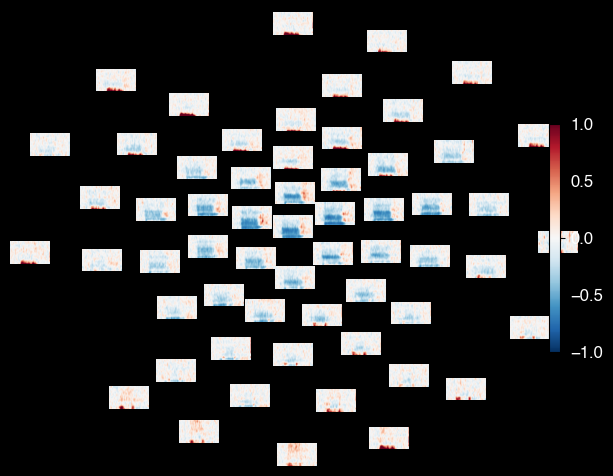

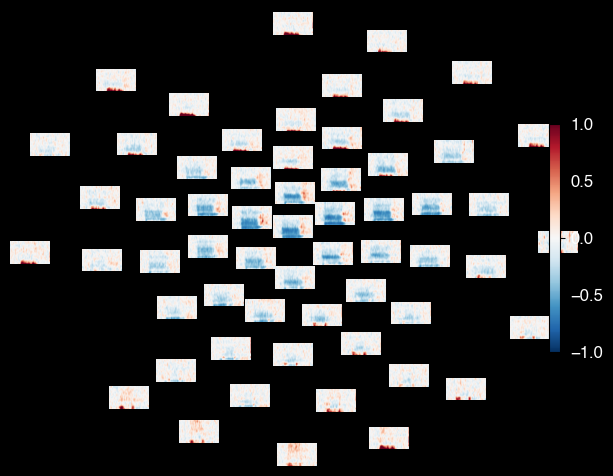

In [9]:
power_all.plot_topo(fmin=10,fmax = 46,baseline=(-1.5, 0), mode="percent",tmin=-1,
                  vmin=-1,vmax=1)

Then we plot from 12-30 Hz and 1-4s

Applying baseline correction (mode: zscore)


/var/folders/lc/2w90j0s17cx3s8fl2m6h2gz80000gn/T/ipykernel_77773/1202238711.py:32: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


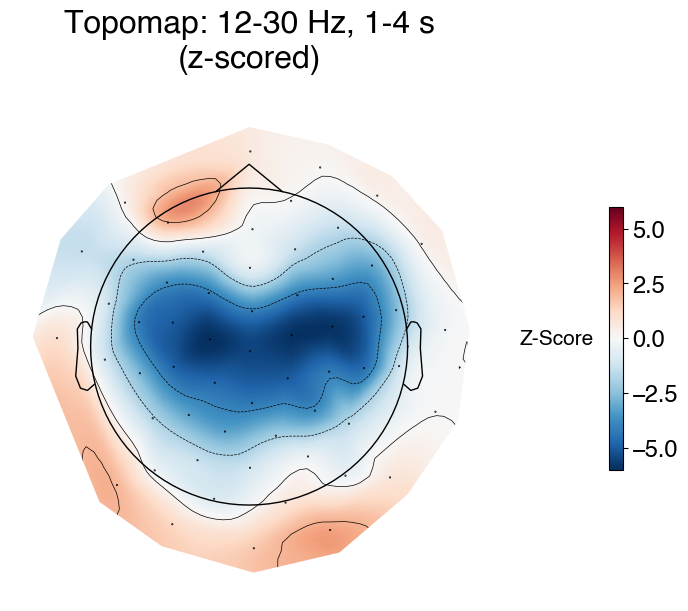

In [10]:
# Plot topomap
fig = power_all.plot_topomap(
    fmin=12,
    fmax=30,
    tmin=1.0,
    tmax=4.0,
    baseline=(-1.5, 0),
    mode="zscore",
    colorbar=False,
    vlim=[-6, 6],
    show = False
)

# Resize the figure
fig.set_size_inches(8, 6)

# Modify colorbar and add title
for ax in fig.axes:
    if hasattr(ax, 'images') and ax.images:
        # Add colorbar
        cbar = fig.colorbar(ax.images[0], ax=ax, shrink=0.5)
        cbar.set_label('Z-Score', fontsize=15)
        cbar.ax.tick_params(labelsize=17)
        cbar.ax.yaxis.set_label_position('left')
        cbar.ax.yaxis.set_label_coords(-4, 0.46)
        cbar.ax.yaxis.label.set_rotation(0)

        # Add title (once, on the first valid axis)
        ax.set_title("Topomap: 12-30 Hz, 1-4 s\n(z-scored)", fontsize=23, fontweight='bold')
        break  # Done with one topomap

fig.show()


### Plot Power in Left vs Right Movement Trials

8-15Hz and 1-4s gives the clearest pattern of hemispheric asymmetry 

Applying baseline correction (mode: zscore)


/var/folders/lc/2w90j0s17cx3s8fl2m6h2gz80000gn/T/ipykernel_77773/4185330802.py:36: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


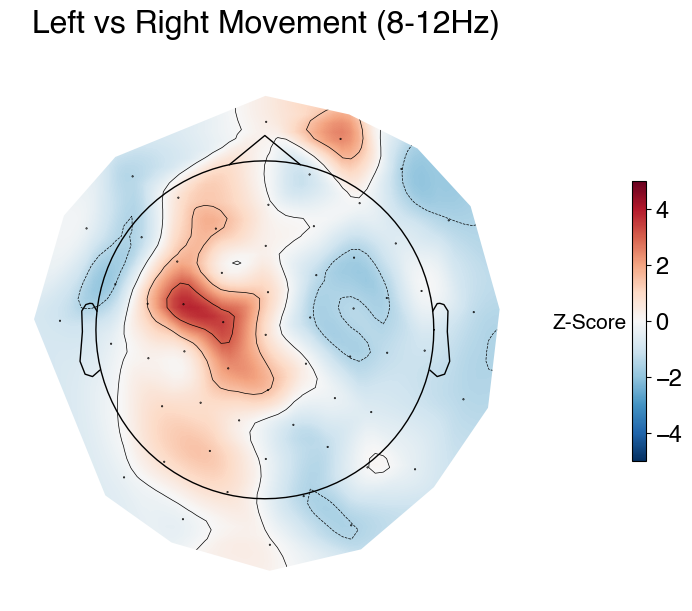

In [11]:
# Compute dB contrast
power_db = power_L.copy()
power_db.data = 20 * np.log10(power_L.data / power_R.data)
# power_db.plot_topo(fmin=10,fmax = 50, tmin=-1, title="Average power")

# Plot topomap (spatial distribution) averaged over 12–30 Hz and 1–4 sec
fig = power_db.plot_topomap(
    fmin=8,
    fmax=15,
    tmin=1.0,
    tmax=4.0,
    baseline=(-1.5, 0),
    mode="zscore",
    colorbar=False,
    vlim = ([-5,5]),
    show=False
)

# Modify colorbar (get from the last axis)
import matplotlib.pyplot as plt
for ax in fig.axes:
    if hasattr(ax, 'images') and ax.images:
        cbar = fig.colorbar(ax.images[0], ax=ax,shrink=0.5)
        cbar.set_label('Z-Score', fontsize=15)
        cbar.ax.tick_params(labelsize=17)
        cbar.ax.yaxis.set_label_position('left')
        cbar.ax.yaxis.set_label_coords(-3, 0.46)
        cbar.ax.yaxis.label.set_rotation(0)
        break  # Only add one colorbar

# Resize the figure to 6x6 inches
fig.set_size_inches(8, 6)

plt.title("Left vs Right Movement (8-12Hz)",fontsize=23,fontweight='bold')

fig.show()